In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [8]:
rows = []
for mouse in sparse_mice:
    for day in range(6):
        if mouse == 'SparseKO_09' and day == 2:
            continue
        sess = u.load_single_day(mouse,day)


        for chan in ('channel_0', 'channel_1'):

            rows.append({
                'mouse': mouse,
                'day': day,
                'channel': chan,
                'num_neurons': sess.timeseries[f'{chan}_F_dff'].shape[0],
            })

df = pd.DataFrame(rows)


{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5}
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': 1, 'exp_day': 3}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1,

In [9]:
df.head()

,mouse,day,channel,num_neurons
0,SparseKO_02,0,channel_0,318
1,SparseKO_02,0,channel_1,70
2,SparseKO_02,1,channel_0,201
3,SparseKO_02,1,channel_1,98
4,SparseKO_02,2,channel_0,287


In [19]:
df.groupby('channel').num_neurons.describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
channel_0,41.0,270.878049,84.571034,140.0,210.0,252.0,303.0,504.0
channel_1,41.0,105.146341,38.914368,31.0,72.0,103.0,128.0,199.0


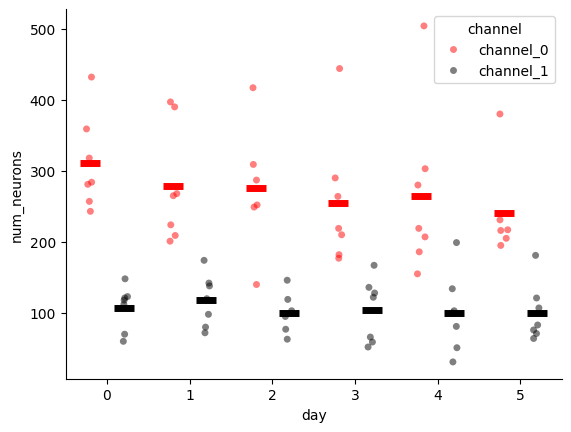

In [18]:
fig, ax = plt.subplots()

sns.stripplot(
    data=df,
    x='day',
    y='num_neurons',
    hue='channel',
    dodge=True,
    ax=ax,
    palette=['red','black'],
    hue_order=['channel_0','channel_1'],
    alpha=0.5,
)

sns.pointplot(
    data=df,
    x='day',
    y='num_neurons',
    hue='channel',
    dodge=.4,
    ax=ax,
    palette=['red','black'],
    hue_order=['channel_0','channel_1'],
    errorbar=None,
    linestyles="none",
    marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)